## Train A Test A

### Classification

Category distribution:
3    23915
6    15692
0    13355
1    12024
5      399
4       41
7       20
2       14
8        9
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.98      0.96      0.97      2705
        Bulb       0.66      0.57      0.61      2411
      Button       0.50      1.00      0.67         1
 Coordinator       0.72      0.79      0.75      4765
        Door       1.00      0.75      0.86         4
      Motion       0.72      0.56      0.63        77
      Socket       0.78      0.78      0.78      3125
 Temperature       1.00      1.00      1.00         3
   Vibration       1.00      0.67      0.80         3

    accuracy                           0.78     13094
   macro avg       0.82      0.79      0.78     13094
weighted avg       0.78      0.78      0.78     13094

Macro F1-Score: 0.7848


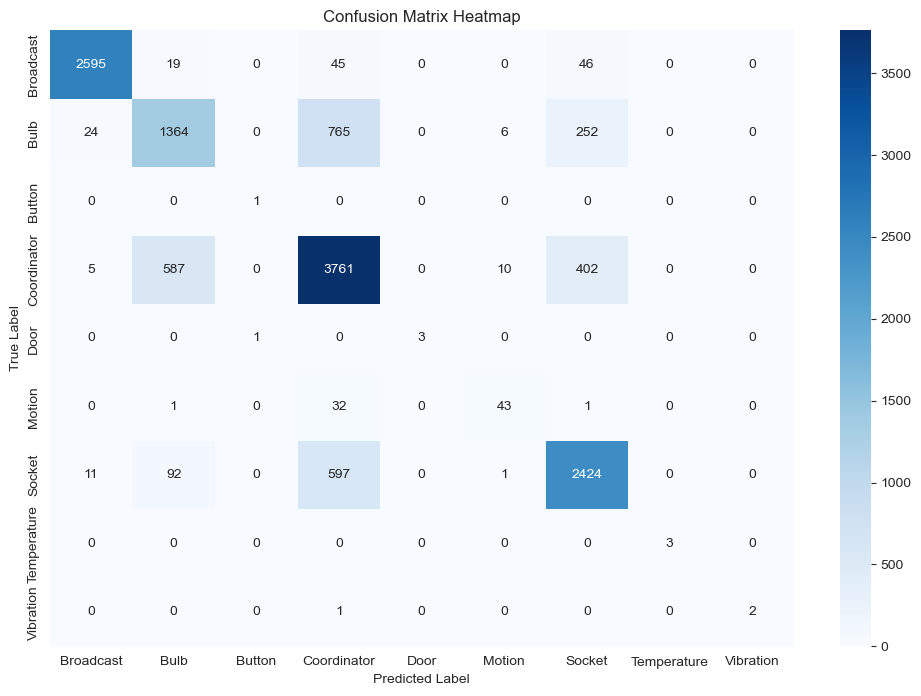

In [1]:
# Classification
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]
cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
# Calculated Macro Average F1-Score
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
6     23915
5     13355
17     4962
16     4656
7      4463
15     3982
14     2324
10     2270
11     1537
12     1430
8      1092
9      1000
13      391
1        21
22       20
0        14
2        10
4         9
19        6
18        4
21        3
3         3
20        2
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       1.00      1.00      1.00         1
        Aqara Door 1       0.00      0.00      0.00         1
        Aqara Door 2       0.50      0.50      0.50         2
        Aqara Motion       0.00      0.00      0.00         1
     Aqara Vibration       1.00      0.33      0.50         3
           Broadcast       0.96      0.96      0.96      2705
         Coordinator       0.67      0.84      0.75      4765
       Ledvance Bulb       0.39      0.30      0.34       897
Ledvance Smart+ Plug       0.75      0.74      0.75       214
    Ledvance Z3 Plug       0.74      0.72      0.73   

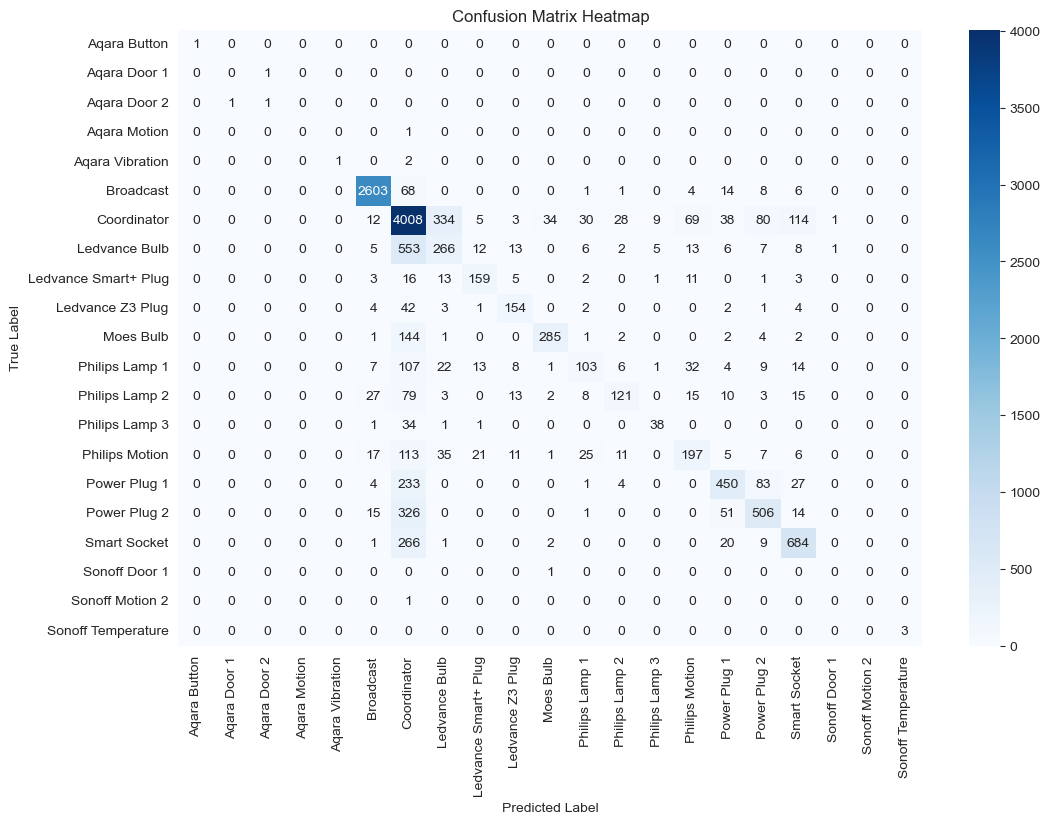

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train B Test B

### Classification

Category distribution:
3    35504
6    24904
0    16926
1    14868
5      818
2      121
4      112
7      106
8       19
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.97      0.97      0.97      3401
        Bulb       0.65      0.54      0.59      2930
      Button       0.96      1.00      0.98        26
 Coordinator       0.72      0.79      0.75      7031
        Door       0.95      0.91      0.93        23
      Motion       0.92      0.72      0.81       163
      Socket       0.79      0.76      0.78      5077
 Temperature       1.00      0.95      0.98        21
   Vibration       1.00      1.00      1.00         4

    accuracy                           0.78     18676
   macro avg       0.89      0.85      0.87     18676
weighted avg       0.78      0.78      0.77     18676

Macro F1-Score: 0.8653


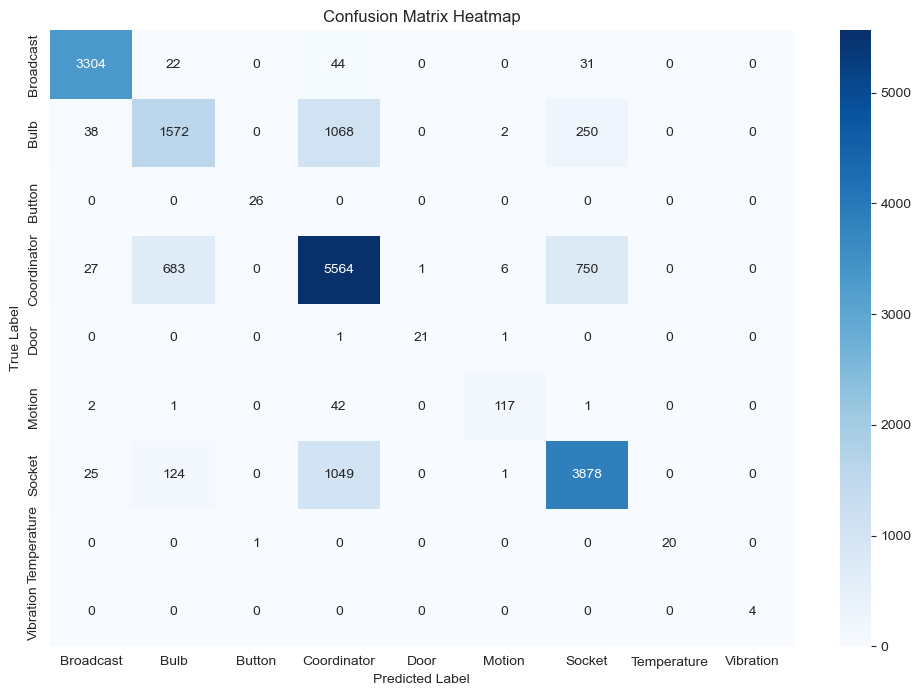

In [3]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Type"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)
f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

### Identification

Category distribution:
6     35504
5     16926
15     8136
17     7901
16     6158
7      4644
11     3767
13     2903
10     2048
9      1806
12     1506
8       903
14      681
0       121
22      106
3        71
20       52
18       34
19       34
1        31
4        19
21       14
2        13
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.92      0.92      0.92        26
        Aqara Door 1       0.91      1.00      0.95        10
        Aqara Motion       0.93      0.93      0.93        14
     Aqara Vibration       1.00      1.00      1.00         4
           Broadcast       0.96      0.98      0.97      3401
         Coordinator       0.69      0.82      0.75      7031
       Ledvance Bulb       0.42      0.33      0.37       903
Ledvance Smart+ Plug       0.75      0.63      0.68       179
    Ledvance Z3 Plug       0.67      0.59      0.62       343
           Moes Bulb       0.81      0.73      0.77   

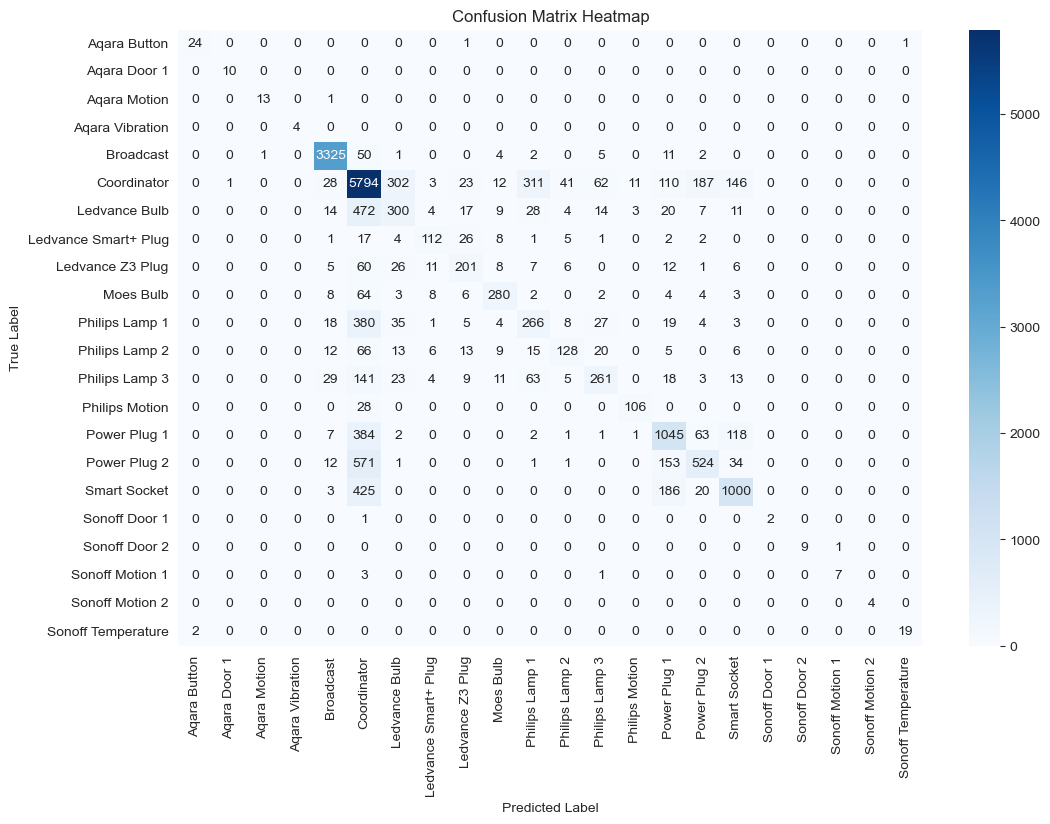

In [4]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
data = pd.read_csv(file_path)

X = data.drop(columns=["Device Name", "Device Type","File Name"])
y = data["Device Name"]

y = y.astype('category')
categories = y.cat.categories  
y = y.cat.codes

print("Category distribution:")
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y).unique(), y=y)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))  

target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()

## Train A Test B

### Classification

Category distribution:
3    23915
6    15692
0    13355
1    12024
5      399
4       41
7       20
2       14
8        9
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.93      0.89      0.91     16926
        Bulb       0.58      0.39      0.47     14868
      Button       0.42      0.33      0.37       121
 Coordinator       0.66      0.78      0.71     35504
        Door       0.63      0.32      0.43       112
      Motion       0.13      0.10      0.11       818
      Socket       0.61      0.61      0.61     24904
 Temperature       0.22      0.06      0.09       106
   Vibration       0.60      0.32      0.41        19

    accuracy                           0.68     93378
   macro avg       0.53      0.42      0.46     93378
weighted avg       0.68      0.68      0.68     93378

Macro F1-Score: 0.4572


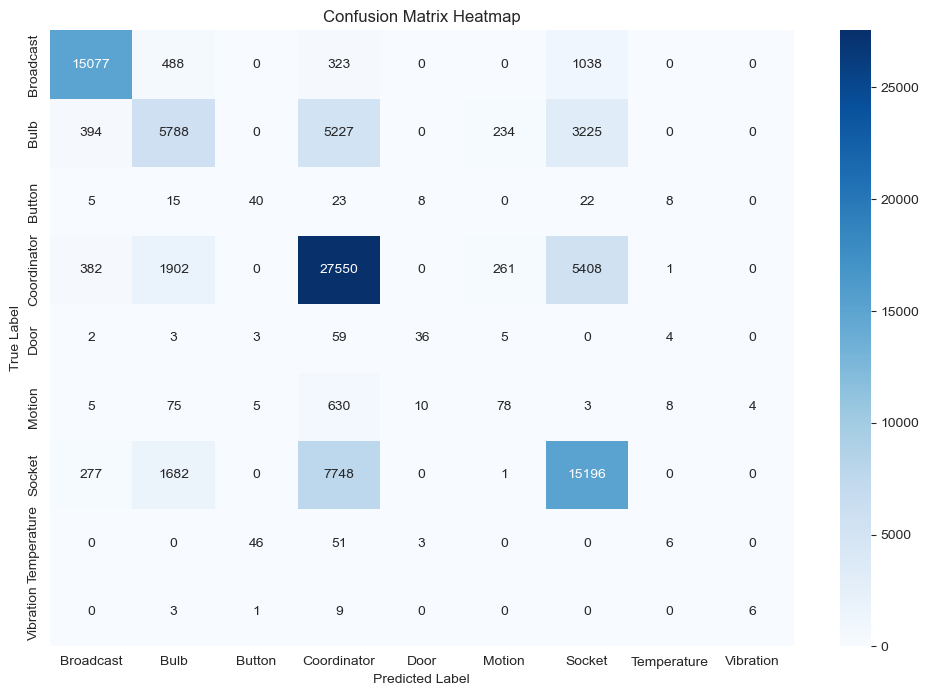

In [5]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
6     23915
5     13355
17     4962
16     4656
7      4463
15     3982
14     2324
10     2270
11     1537
12     1430
8      1092
9      1000
13      391
1        21
22       20
0        14
2        10
4         9
19        6
18        4
21        3
3         3
20        2
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.43      0.31      0.36       121
        Aqara Door 1       0.40      0.26      0.31        31
        Aqara Door 2       0.00      0.00      0.00        13
        Aqara Motion       1.00      0.03      0.05        71
     Aqara Vibration       0.00      0.00      0.00        19
           Broadcast       0.89      0.91      0.90     16926
         Coordinator       0.59      0.90      0.71     35504
       Ledvance Bulb       0.32      0.08      0.13      4644
Ledvance Smart+ Plug       0.09      0.05      0.07       903
    Ledvance Z3 Plug       0.30      0.29      0.30   

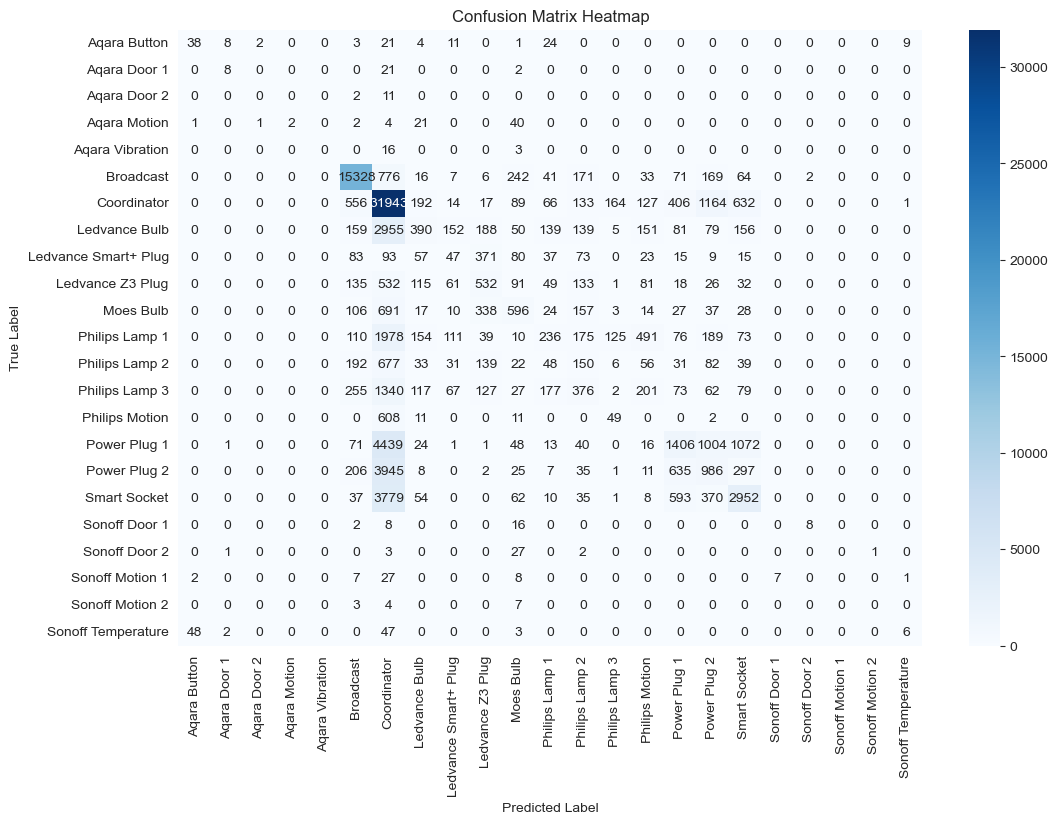

In [6]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


## Train B Test A

### Classification

Category distribution:
3    35504
6    24904
0    16926
1    14868
5      818
2      121
4      112
7      106
8       19
Name: count, dtype: int64
              precision    recall  f1-score   support

   Broadcast       0.96      0.90      0.93     13355
        Bulb       0.64      0.37      0.47     12024
      Button       0.29      0.43      0.34        14
 Coordinator       0.65      0.85      0.74     23915
        Door       0.36      0.12      0.18        41
      Motion       0.29      0.15      0.20       399
      Socket       0.69      0.63      0.66     15692
 Temperature       0.26      0.25      0.26        20
   Vibration       0.00      0.00      0.00         9

    accuracy                           0.72     65469
   macro avg       0.46      0.41      0.42     65469
weighted avg       0.72      0.72      0.70     65469

Macro F1-Score: 0.4197


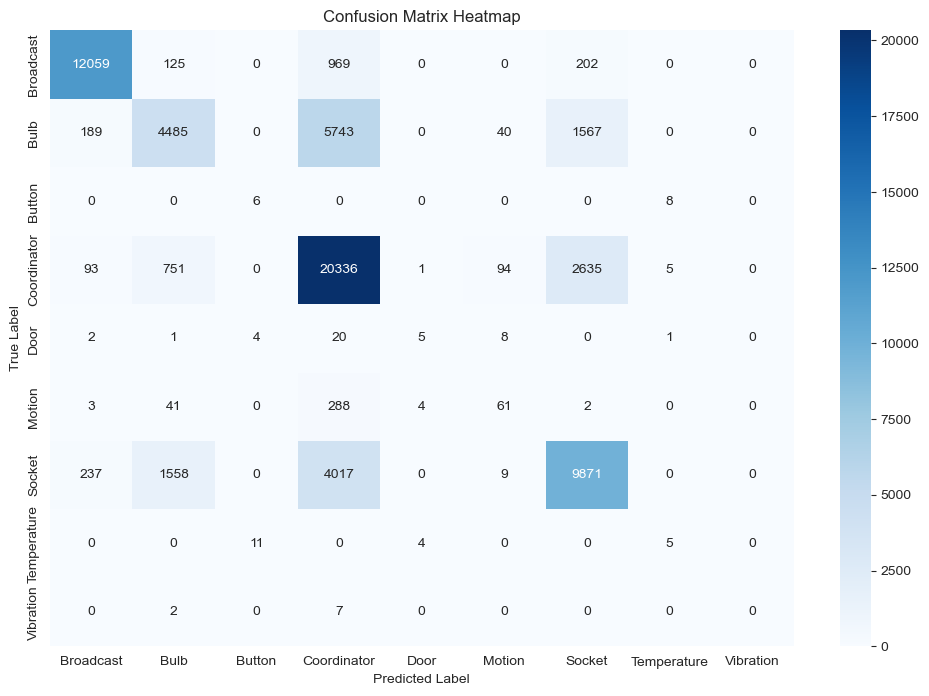

In [7]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Type"]
y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Type"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes


class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()


### Identification

Category distribution:
6     35504
5     16926
15     8136
17     7901
16     6158
7      4644
11     3767
13     2903
10     2048
9      1806
12     1506
8       903
14      681
0       121
22      106
3        71
20       52
18       34
19       34
1        31
4        19
21       14
2        13
Name: count, dtype: int64
                      precision    recall  f1-score   support

        Aqara Button       0.32      0.50      0.39        14
        Aqara Door 1       1.00      0.05      0.09        21
        Aqara Door 2       0.00      0.00      0.00        10
        Aqara Motion       0.25      0.67      0.36         3
     Aqara Vibration       0.00      0.00      0.00         9
           Broadcast       0.94      0.91      0.93     13355
         Coordinator       0.61      0.88      0.72     23915
       Ledvance Bulb       0.36      0.22      0.27      4463
Ledvance Smart+ Plug       0.24      0.08      0.12      1092
    Ledvance Z3 Plug       0.37      0.36      0.36   

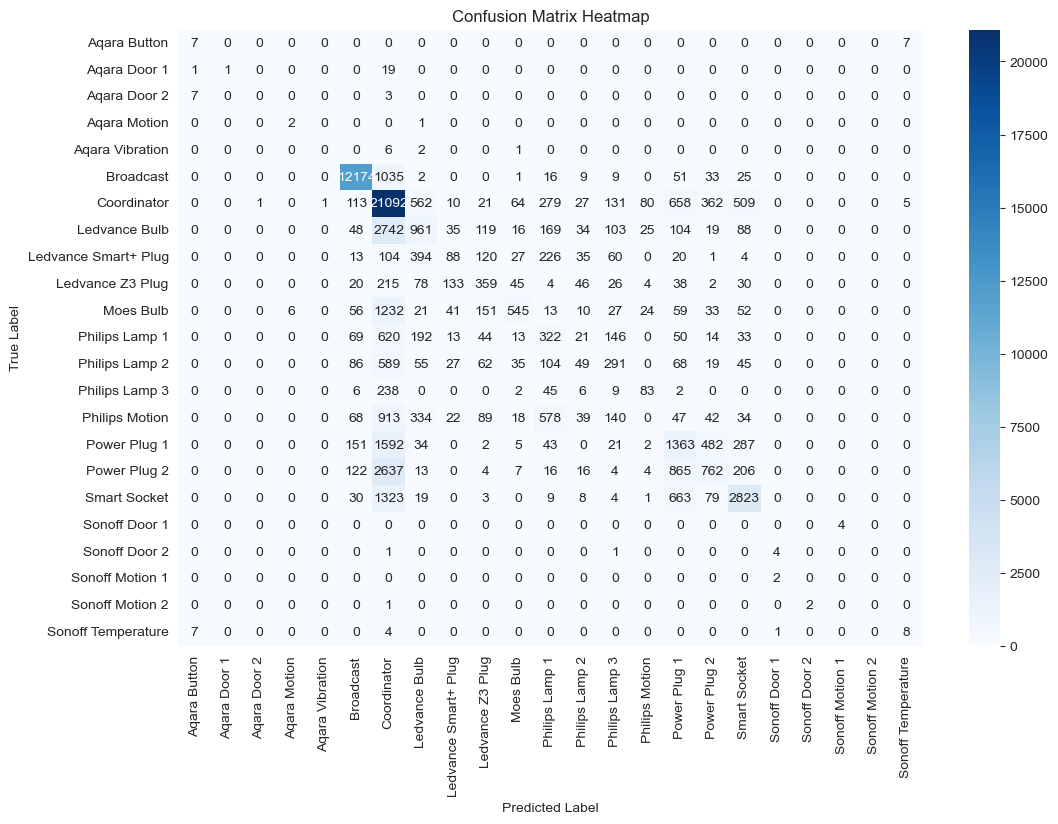

In [8]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

train_file_path = "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_B_fix_packets.csv"
train_data = pd.read_csv(train_file_path)

X_train = train_data.drop(columns=["Device Name", "Device Type","File Name"])
y_train = train_data["Device Name"]

y_train = y_train.astype('category')
categories = y_train.cat.categories
y_train = y_train.cat.codes

print("Category distribution:")
print(pd.Series(y_train).value_counts())

test_file_path =  "./Merged_Data/A_6-Merged_sequence_data_fix_packets/Topology_A_fix_packets.csv"
test_data = pd.read_csv(test_file_path)

X_test = test_data.drop(columns=["Device Name", "Device Type","File Name"])
y_test = test_data["Device Name"]

y_test = y_test.astype('category')
y_test = y_test.cat.codes

class_weights = compute_class_weight(class_weight="balanced", classes=pd.Series(y_train).unique(), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

rf_model = RandomForestClassifier(random_state=42, class_weight=class_weight_dict)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
actual_categories = sorted(set(y_test) | set(y_pred))
target_names = [categories[i] for i in actual_categories]

cm = confusion_matrix(y_test, y_pred, labels=actual_categories)

report = classification_report(y_test, y_pred, target_names=target_names, labels=actual_categories, zero_division=0)
print(report)

f1_macro = f1_score(y_test, y_pred, average="macro")
print(f"Macro F1-Score: {f1_macro:.4f}")

plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap")
plt.show()
